### **Geo-Energy Engineering Application Final Project (Q3, 2026)**

### Project I [50% total weight]:

**Description:**

A single-phase 1D hydrogen storage reservoir (of length L) is at an initial pressure of P(x, t=0) = 100 bars everywhere, having hydrogen stored during summer. The left and right boundaries are sealed, i.e., they both exhibit "no-flow" condition. Suddenly, a power shortage happens, and we need to produce hydrogen from this reservoir from the production well located at x = L/2. The well radius is 0.15 m, with skin S = 2, and the operational pressure is set to the content value of P_BHP = 20 bars.

**Wanted:**

Simulate the pressure distribution, mass velocity field (ρ, U), and cumulative hydrogen gas production from the start of production until the average pressure in the reservoir reaches half of the original pressure, i.e., until P_avg = 50 bars. Simulate it for the base case grid size (given below) and also study the impact of grid size on the results by using 10 times less and 10 times more grid cells.

**Given:**

- Assume the reservoir is homogeneous with K = 1 Darcy and L = 100 m.  
- Use Δx = 1 m as the base case (leading to 100 grid cells as the base case).  
- Hydrogen density can be approximated by the ideal gas law, ρ / ρ₀ = P / P₀, where ρ₀ = 0.1 kg/m³ at p₀ = 10 bars.  
- Porosity is 0.2.  
- Assume all other necessary data.

**Report & Grading:**

1. Describe the governing equations, discretization and simulation approach **[10%]**

2. Simulate the pressure distribution: plot the results and explain and justify what they mean **[25%]**

3. Simulate the mass velocity field (ρ, U): plot the results and explain and justify what they mean **[25%]**

4. Simulate the cumulative hydrogen gas production (mass and volume): plot the results and explain and justify what they mean **[25%]**

5. Use 10 times coarser and 10 times finer grid cells and plot and discuss the impact of grid size on the results **[15%]**

### *Calculation / Graph Plotting / COdes for Project I:*

#### 1. Governing equations, discretization and simulation approach [10%]

**Governing PDE:**

$$\phi c_g \frac{\partial p}{\partial t} = \frac{k}{\mu}\frac{\partial^2 p}{\partial x^2} + \frac{q}{\rho}$$

where:
- $c_g = 1/p$ = gas compressibility (ideal gas)
- $\rho(p) = \rho_0 p/p_0$ = density (ideal gas law)

**Discretization (Finite Volume, fully implicit):**

$$\Theta_i (p_i^{n+1} - p_i^n) = F_{i-1/2}^{n+1} - F_{i+1/2}^{n+1} + Q_i^{n+1}$$

where:
- $\Theta_i = V_i \phi / \Delta t$ = accumulation coefficient
- $F_{i+1/2} = T \rho_{i+1/2}^{upwind} (p_{i+1} - p_i)$ = mass flux (upwind density)
- $T = kA/(\mu \Delta x)$ = transmissibility
- $Q_i$ = well term

**Well Model (Peaceman):**

$$Q_w = \Gamma_w (p_{i_w}^{n+1} - p_{bhp})$$

$$\Gamma_w = \frac{2\pi k h}{\mu[\ln(r_0/r_w) + S]} \qquad r_0 = 0.208\Delta x$$

where:
- $Q_w$ = well production rate [m³/s]
- $p_{i_w}$ = grid block pressure at well location (cell 50)
- $p_{bhp} = 20$ bar = bottom-hole pressure constraint
- $\Gamma_w$ = productivity index
- $r_0$ = equivalent wellbore radius (Peaceman correction)
- $r_w = 0.15$ m, $S = 2$ = wellbore radius and skin factor


---

#### 2. Pressure Distribution Simulation [25%]

*Implementation based on Reservoir Numerical Simmulation Lecture Note: Practical 5-7 connection list framework with Peaceman well model:*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve


# Physical parameters (SI units)
L = 100.0                    # Reservoir length [m]
phi = 0.2                    # Porosity
k = 1.0 * 9.87e-13           # Permeability [m2] (1 Darcy)
mu = 8.9e-6                  # Hydrogen viscosity [Pa.s]
rho_0 = 0.1                  # Reference density [kg/m2]
p_0 = 10.0 * 1e5             # Reference pressure [Pa] (10 bar)
p_init = 100.0 * 1e5         # Initial pressure [Pa] (100 bar)
p_bhp = 20.0 * 1e5           # Bottom-hole pressure [Pa] (20 bar)
rw = 0.15                    # Wellbore radius [m]
S = 2.0                      # Skin factor


# Grid parameters (base case)
nx = 100
dx = L / nx
dy = dz = 1.0                # Unit cross-section [m]
A = dy * dz                  # Cross-sectional area [m2]
V_cell = dx * A              # Cell volume [m3]


# Well location (center)
iw = nx // 2


# Transmissibility
T = k * A / (mu * dx)               # [m3/s/Pa]


# Peaceman well index
r0 = 0.208 * dx                     # Equivalent wellbore radius
WI = 2 * np.pi * k * dz / (mu * (np.log(r0 / rw) + S))  # [m3/s/Pa]


# Time stepping
dt = 0.1                            # Initial time step [s] (0.1 second)
dt_max = 10.0                       # Maximum time step [s] (10 seconds)
mult_dt = 1.05                      # Time step multiplier (slower growth)


# Initialize solution arrays
p = np.ones(nx) * p_init            # Pressure [Pa]
time = 0.0
time_history = [0.0]
p_avg_history = [p_init / 1e5]      # [bar]


# Storage for plotting at selected times
plot_times = [0.0]                  # Start with t=0
plot_pressures = [p.copy() / 1e5]   # Store initial condition in bar
p_avg_thresholds = [90, 70, 50]     # Store observation points at these p_avg values
stored_thresholds = []              # Tracked thresholds


# Cumulative production tracking
M_cum = 0.0                         # Cumulative mass produced [kg]
V_cum_std = 0.0                     # Cumulative volume std. cond. [m3]
M_cum_history = [0.0]
V_cum_history = [0.0]


def assemble_system(p_current, dt_current):
    """Assemble tridiagonal system M*p_new = f"""
    M = lil_matrix((nx, nx))
    f = np.zeros(nx)
    

    # Density [kg/m³]
    rho = rho_0 * p_current / p_0
    Theta = V_cell * phi / dt_current
    

    for i in range(nx):
        # Accumulation: Θ(ρ^{n+1} - ρ^n)
        M[i, i] += Theta * rho_0 / p_0
        f[i] += Theta * rho[i]
        

        # Left flux (sealed at i=0)
        if i > 0:
            rho_up = rho_0 * max(p_current[i-1], p_current[i]) / p_0  # Upwind density
            M[i, i] += T * rho_up
            M[i, i-1] -= T * rho_up
        

        # Right flux (sealed at i=nx-1)
        if i < nx - 1:
            rho_up = rho_0 * max(p_current[i], p_current[i+1]) / p_0  # Upwind density
            M[i, i] += T * rho_up
            M[i, i+1] -= T * rho_up
        

        # Well term
        if i == iw:
            rho_w = rho_0 * p_current[i] / p_0
            M[i, i] += WI * rho_w
            f[i] += WI * rho_w * p_bhp
    

    return M.tocsr(), f


# Time-stepping loop
step = 0
while np.mean(p) > 50.0 * 1e5:  # Continue until average pressure < 50 bar
    

    # Production rate
    rho_w_curr = rho_0 * p[iw] / p_0
    Q_mass = WI * rho_w_curr * (p[iw] - p_bhp)          # [kg/s]
    Q_vol_std = WI * (p[iw] - p_bhp) * p[iw] / p_0      # [m3_std/s]
    M_cum += Q_mass * dt
    V_cum_std += Q_vol_std * dt
    

    # Assemble and solve
    M, f = assemble_system(p, dt)
    p_new = spsolve(M, f)
    

    # Update
    p = p_new
    time += dt
    step += 1
    

    # Store history
    time_history.append(time)
    p_avg = np.mean(p) / 1e5        # [bar]
    p_avg_history.append(p_avg)
    M_cum_history.append(M_cum)
    V_cum_history.append(V_cum_std)
    

    # Store observation points when crossing p_avg thresholds
    for threshold in p_avg_thresholds:
        if p_avg <= threshold and threshold not in stored_thresholds:
            plot_times.append(time)
            plot_pressures.append(p.copy() / 1e5)
            stored_thresholds.append(threshold)
            print(f"Observation point: p_avg = {p_avg:.1f} bar at t = {time:.1f} s")
            break
    

    # Adaptive time stepping
    dt = min(dt * mult_dt, dt_max)
    
    if step % 500 == 0:
        print(f"Step {step}: t = {time:.2f} s, p_avg = {p_avg:.2f} bar")


print(f"Average pressure: {np.mean(p)/1e5:.2f} bar")
print(f"Total mass produced: {M_cum:.3f} kg")
print(f"Total volume produced: {V_cum_std:.3f} m3 (at p0 = 10 bar)")

Observation point: p_avg = 89.9 bar at t = 12.8 s
Observation point: p_avg = 69.9 bar at t = 107.3 s
Observation point: p_avg = 49.7 bar at t = 324.1 s
Average pressure: 49.71 bar
Total mass produced: 10.452 kg
Total volume produced: 104.524 m3 (at p0 = 10 bar)


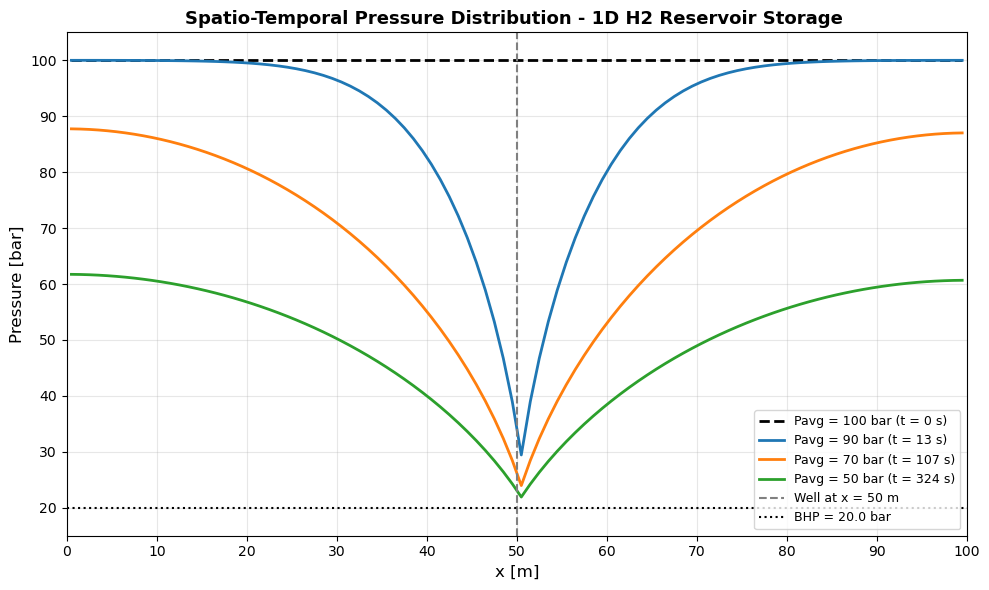

In [40]:
# Task 2 Project 1: Simulating the pressure distribution at selected times for plotting

x = np.linspace(dx/2, L - dx/2, nx)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))


# Plotting all observation points
for i, (t, p_profile) in enumerate(zip(plot_times, plot_pressures)):
    p_avg = np.mean(p_profile)

    if i == 0:  # Initial condition (100 bar)
        ax.plot(x, p_profile, 'k--', label=f'Pavg = {p_avg:.0f} bar (t = {t:.0f} s)', linewidth=2)

    else:  # Other timesteps - colored solid lines
        ax.plot(x, p_profile, label=f'Pavg = {p_avg:.0f} bar (t = {t:.0f} s)', linewidth=2)


# Reference lines
ax.axvline(x=L/2, color='gray', linestyle='--', linewidth=1.5, label='Well at x = 50 m')
ax.axhline(y=20, color='k', linestyle=':', linewidth=1.5, label='BHP = 20.0 bar')


ax.set_xlabel('x [m]', fontsize=12)
ax.set_ylabel('Pressure [bar]', fontsize=12)
ax.set_title(f'Spatio-Temporal Pressure Distribution - 1D H2 Reservoir Storage ', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, L)
ax.set_ylim(15, 105)
ax.set_xticks(np.arange(0, L+1, 10))  # x-axis ticks every 10 m


plt.tight_layout()
plt.show()

---

#### 3. Mass Velocity Field (ρU) Simulation [25%]

*Mass velocity ρU [kg/(m²·s)] at cell faces computed using Darcy's law with upwind density weighting, using the same simulation data from Section 2:*

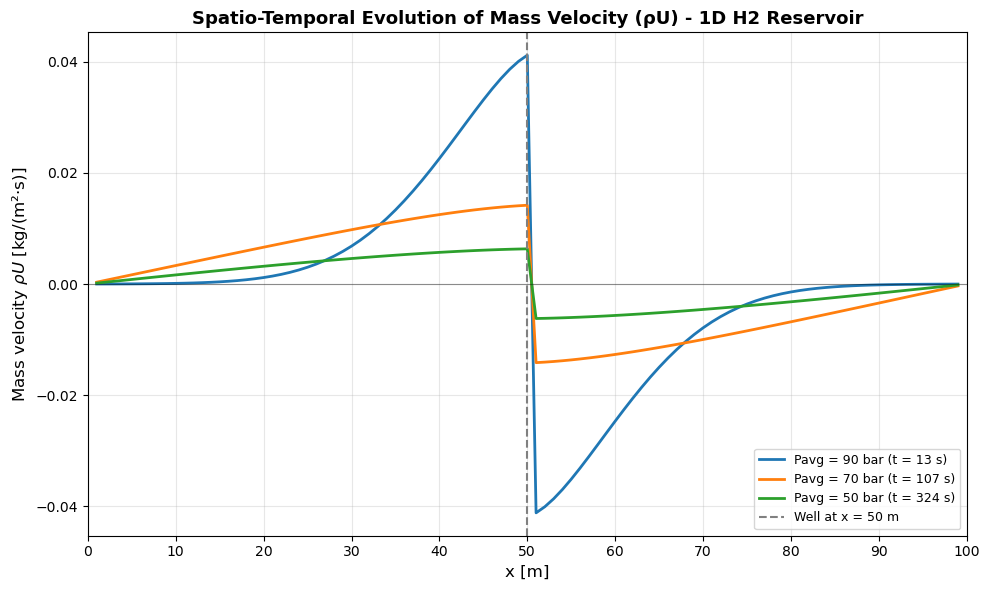

In [ ]:
# Task 3 Project 1: Mass velocity field (ρU) at cell faces

x_face = np.arange(1, nx) * dx  # Face positions [m]

fig, ax = plt.subplots(1, 1, figsize=(10, 6))


# Computing and plotting ρU at each observation point (skip t=0)
for t, p_profile in zip(plot_times[1:], plot_pressures[1:]):
    p_Pa = p_profile * 1e5  # Convert bar to Pa

    u_face = -(k / mu) * np.diff(p_Pa) / dx  # Darcy velocity [m/s]


    # Upwind density
    rho_face = rho_0 * np.where(u_face > 0, p_Pa[:-1], p_Pa[1:]) / p_0  # Upwind density [kg/m3]


    # Mass velocity [kg/(m2·s)]
    rho_u = rho_face * u_face

    p_avg = np.mean(p_profile)
    ax.plot(x_face, rho_u, label=f'Pavg = {p_avg:.0f} bar (t = {t:.0f} s)', linewidth=2)


ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.4)
ax.axvline(x=L/2, color='gray', linestyle='--', linewidth=1.5, label='Well at x = 50 m')
ax.set_xlabel('x [m]', fontsize=12)
ax.set_ylabel(r'Mass velocity $\rho U$ [kg/(m²·s)]', fontsize=12)
ax.set_title('Spatio-Temporal Evolution of Mass Velocity (ρU) - 1D H2 Reservoir', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, L)
ax.set_xticks(np.arange(0, L+1, 10))

plt.tight_layout()
plt.show()

---

#### 4. Cumulative Hydrogen Gas Production [25%]

*Cumulative mass [kg] and volume at standard conditions [m³] integrated from the well production rate $Q_{mass} = \Gamma_w \rho_w (p_{well} - p_{bhp})$ at each timestep:*

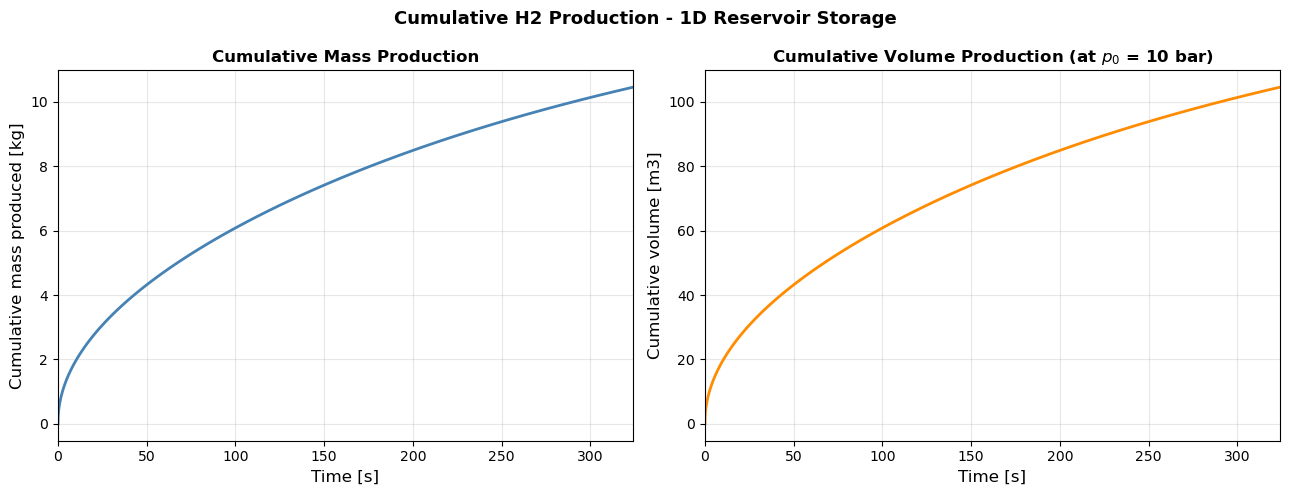

Total mass produced:   10.452 kg
Total volume produced: 104.524 m3 (at p0 = 10 bar)


In [41]:
# Section 4: Calculation of Cumulative hydrogen production (mass and volume)


time_arr = np.array(time_history)
M_arr = np.array(M_cum_history)
V_arr = np.array(V_cum_history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))


# Left plot: Cumulative mass
ax1.plot(time_arr, M_arr, color='steelblue', linewidth=2)
ax1.set_xlabel('Time [s]', fontsize=12)
ax1.set_ylabel('Cumulative mass produced [kg]', fontsize=12)
ax1.set_title('Cumulative Mass Production', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, time_arr[-1])


# Right plot: Cumulative volume
ax2.plot(time_arr, V_arr, color='darkorange', linewidth=2)
ax2.set_xlabel('Time [s]', fontsize=12)
ax2.set_ylabel('Cumulative volume [m3]', fontsize=12)
ax2.set_title('Cumulative Volume Production (at $p_0$ = 10 bar)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, time_arr[-1])

fig.suptitle('Cumulative H2 Production - 1D Reservoir Storage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total mass produced:   {M_arr[-1]:.3f} kg")
print(f"Total volume produced: {V_arr[-1]:.3f} m3 (at p0 = 10 bar)")

---

#### 5. Grid Sensitivity Analysis [15%]

*Simulation repeated for nx = 10 (coarse), nx = 100 (base), and nx = 1000 (fine). All other parameters unchanged:*

In [42]:
# Task 5 Project 1: Grid sensitivity analysis (nx = 10, 100, 1000 (10x coarser and 10x finer than base case of 100))


import time as timer


def run_sim(nx_s):
    """Run FIM simulation for nx_s grid cells."""
    dx_s = L / nx_s
    T_s  = k * A / (mu * dx_s)
    iw_s = nx_s // 2
    WI_s = 2 * np.pi * k * dz / (mu * (np.log(0.208 * dx_s / rw) + S))
    Vc_s = dx_s * A


    p_s = np.ones(nx_s) * p_init
    dt_s = 0.1; t_s = 0.0
    t_hist = [0.0]; M_hist = [0.0]; V_hist = [0.0]
    M_s = 0.0; V_s = 0.0
    obs = {}; stored = []


    while np.mean(p_s) > 50e5:
        rho_ws = rho_0 * p_s[iw_s] / p_0
        M_s += WI_s * rho_ws * (p_s[iw_s] - p_bhp) * dt_s
        V_s += WI_s * (p_s[iw_s] - p_bhp) * p_s[iw_s] / p_0 * dt_s


        mat = lil_matrix((nx_s, nx_s)); fv = np.zeros(nx_s)
        rho_s = rho_0 * p_s / p_0; Th = Vc_s * phi / dt_s


        for i in range(nx_s):
            mat[i, i] += Th * rho_0 / p_0; fv[i] += Th * rho_s[i]
            if i > 0:
                ru = rho_0 * max(p_s[i-1], p_s[i]) / p_0
                mat[i, i] += T_s * ru; mat[i, i-1] -= T_s * ru
            if i < nx_s - 1:
                ru = rho_0 * max(p_s[i], p_s[i+1]) / p_0
                mat[i, i] += T_s * ru; mat[i, i+1] -= T_s * ru
            if i == iw_s:
                rw_s = rho_0 * p_s[i] / p_0
                mat[i, i] += WI_s * rw_s; fv[i] += WI_s * rw_s * p_bhp


        p_s = spsolve(mat.tocsr(), fv)
        t_s += dt_s; t_hist.append(t_s)
        p_avg_s = np.mean(p_s) / 1e5
        M_hist.append(M_s); V_hist.append(V_s)


        for thr in [90, 70, 50]:
            if p_avg_s <= thr and thr not in stored:
                obs[thr] = (t_s, p_s.copy() / 1e5); stored.append(thr)


        dt_s = min(dt_s * mult_dt, dt_max)


    x_s = np.linspace(dx_s/2, L - dx_s/2, nx_s)
    return {'x': x_s, 'obs': obs, 't': np.array(t_hist),
            'M': np.array(M_hist), 'V': np.array(V_hist)}


# Running all grid sizes
grid_results = {}
for nx_g in [10, 100, 1000]:
    t0 = timer.time()
    grid_results[nx_g] = run_sim(nx_g)
    print(f"nx={nx_g:5d} ; M_total = {grid_results[nx_g]['M'][-1]:.3f} kg ; Computation time = {timer.time()-t0:.1f} s")

nx=   10 ; M_total = 10.397 kg ; Computation time = 0.0 s
nx=  100 ; M_total = 10.452 kg ; Computation time = 0.2 s
nx= 1000 ; M_total = 33.035 kg ; Computation time = 3.1 s


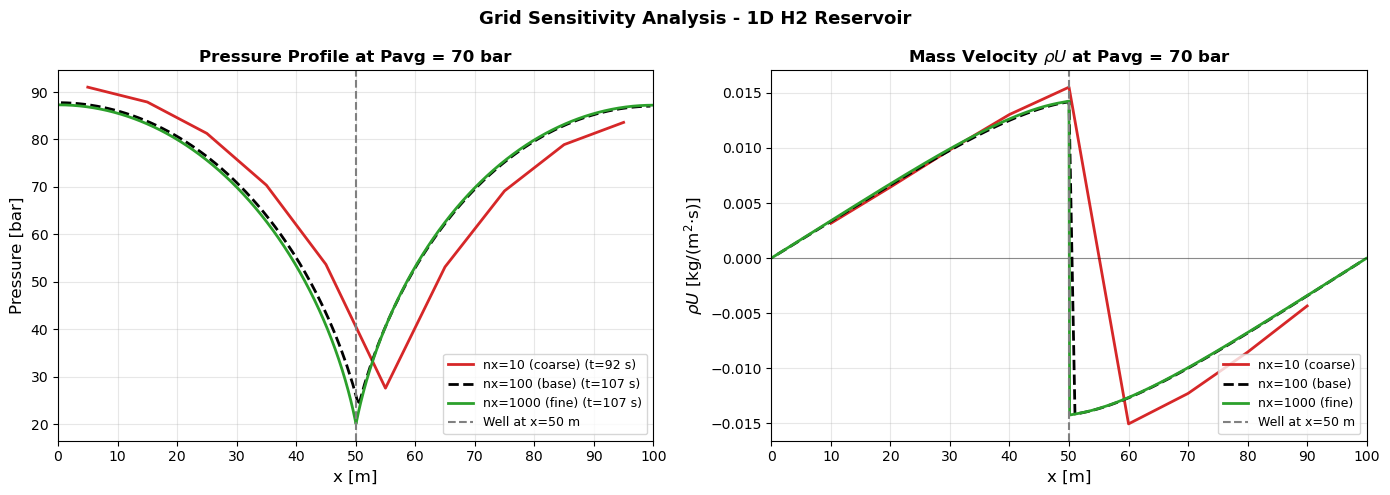

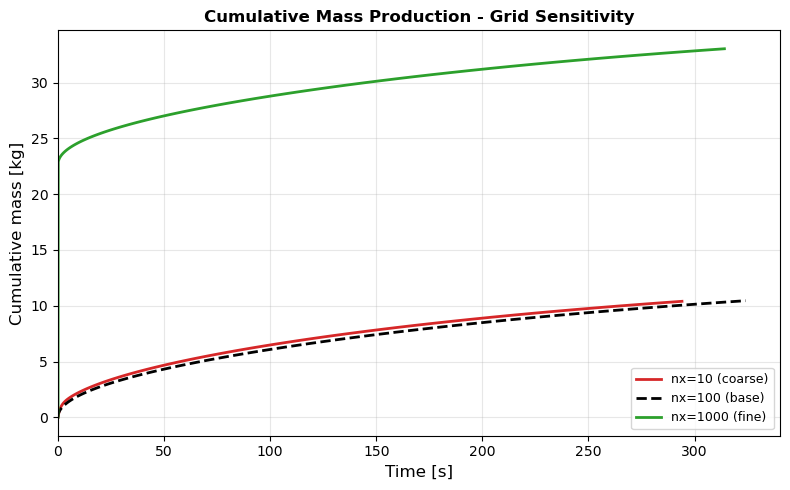

In [43]:
# Additionals: Plotting results for grid sensitivity analysis

colors = {10: 'tab:red', 100: 'k', 1000: 'tab:green'}
linestyles = {10: '-', 100: '--', 1000: '-'}
labels = {10: 'nx=10 (coarse)', 100: 'nx=100 (base)', 1000: 'nx=1000 (fine)'}



# Plot 1: Pressure and mass velocity side by side at Pavg = 70 bar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for nx_g, res in grid_results.items():
    if 70 in res['obs']:
        t70, p70 = res['obs'][70]
        ax1.plot(res['x'], p70, color=colors[nx_g], linestyle=linestyles[nx_g],
                 label=f"{labels[nx_g]} (t={t70:.0f} s)", linewidth=2)
ax1.axvline(x=L/2, color='gray', linestyle='--', linewidth=1.5, label='Well at x=50 m')
ax1.set_xlabel('x [m]', fontsize=12); ax1.set_ylabel('Pressure [bar]', fontsize=12)
ax1.set_title('Pressure Profile at Pavg = 70 bar', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='lower right'); ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, L); ax1.set_xticks(np.arange(0, L+1, 10))


for nx_g, res in grid_results.items():
    if 70 in res['obs']:
        _, p70 = res['obs'][70]
        p_Pa = p70 * 1e5
        dx_g = L / nx_g
        u_f = -(k / mu) * np.diff(p_Pa) / dx_g
        rho_f = rho_0 * np.where(u_f > 0, p_Pa[:-1], p_Pa[1:]) / p_0
        x_f = np.arange(1, nx_g) * dx_g
        ax2.plot(x_f, rho_f * u_f, color=colors[nx_g], linestyle=linestyles[nx_g], label=labels[nx_g], linewidth=2)


ax2.axhline(y=0, color='k', linewidth=0.8, alpha=0.4)
ax2.axvline(x=L/2, color='gray', linestyle='--', linewidth=1.5, label='Well at x=50 m')
ax2.set_xlabel('x [m]', fontsize=12); ax2.set_ylabel(r'$\rho U$ [kg/(m$^2$·s)]', fontsize=12)
ax2.set_title(r'Mass Velocity $\rho U$ at Pavg = 70 bar', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='lower right'); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, L); ax2.set_xticks(np.arange(0, L+1, 10))


fig.suptitle('Grid Sensitivity Analysis - 1D H2 Reservoir', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



# Plot 2: Cumulative mass production
fig2, ax3 = plt.subplots(1, 1, figsize=(8, 5))
for nx_g, res in grid_results.items():
    ax3.plot(res['t'], res['M'], color=colors[nx_g], linestyle=linestyles[nx_g], label=labels[nx_g], linewidth=2)
ax3.set_xlabel('Time [s]', fontsize=12); ax3.set_ylabel('Cumulative mass [kg]', fontsize=12)
ax3.set_title('Cumulative Mass Production - Grid Sensitivity', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9, loc='lower right'); ax3.grid(True, alpha=0.3); ax3.set_xlim(0)
plt.tight_layout()
plt.show()